# 📊 **Machine Learning Task: Customer Churn Prediction (Classification)**

## 🧠 **Problem Statement :**
Customer churn is a major challenge for telecom companies as it leads to revenue loss and higher customer acquisition costs. In this project, the objective is to build a Machine Learning classification model to predict whether a customer will churn (Yes/No) using a dataset containing demographic details (such as gender and senior citizen status), account information (tenure, contract type, billing and payment methods), service usage features (internet service, online security, tech support, streaming services), and financial attributes (monthly and total charges). The goal is to preprocess and analyze the data, perform feature engineering, train and compare multiple classification models, and identify the most effective model to accurately predict customer churn, helping businesses take proactive steps to improve customer retention.


## 🎯 Objective
The main objective of this project is to build a Machine Learning model that can predict whether a customer will leave the company or not. By using customer data like personal details, services used, and billing information, the model helps identify customers who are likely to churn, so the company can take early actions to retain them and reduce losses.


### **1. Import Required Libraries**

In [76]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Load the Dataset**

In [77]:
df = pd.read_csv("telecom_churn_data (1).csv")

### **3. Check Dataset**

● Shape

In [78]:
df.shape #rows and columns

(7043, 21)

● Columns

In [79]:
df.columns # feature names

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

● Data types

In [80]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [81]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [82]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


● Summary statistics

In [83]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### **4. Handle Missing Values**

In [84]:
df.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Since gender and papperlessbilling is a categorical column, the best way is to fill it with the most frequent value (mode):

In [85]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

df['PaperlessBilling'] = df['PaperlessBilling'].fillna(df['PaperlessBilling'].mode()[0])


 For numerical columns, the 'mean' (average value) is commonly used to fill missing data.

In [86]:
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].mean())

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with the mean after conversion
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [87]:
#check
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [88]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


### **5. Remove Duplicate Records**

In [89]:
#check duplicates
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset, indicating the data is clean and consistent.

### **6. Perform Univariate Analysis**

● Distribution of Numerical Features

In [90]:
# Step 1: Select numerical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

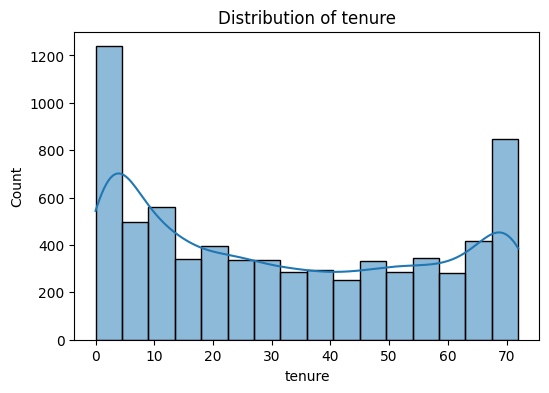

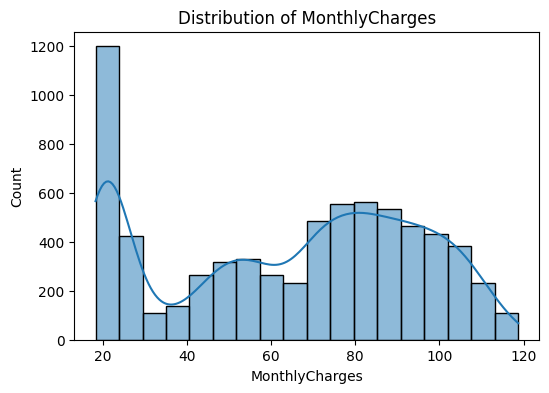

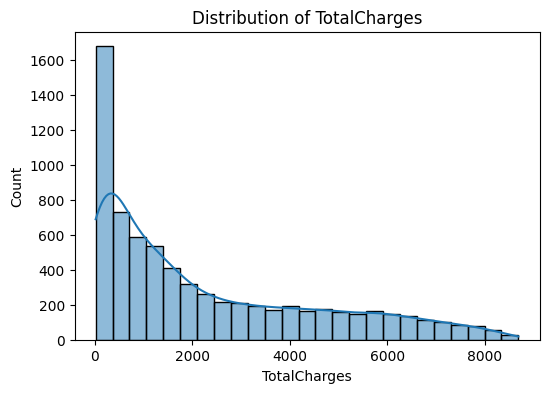

In [91]:
# Step 2: Plot distributions

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

**Insight:**

**Senior Citizen** :Most customers are not senior citizens, with only a small portion belonging to the senior citizen category.

**Tenure:** Most customers have low tenure, meaning many are new customers.

**MonthlyCharges:** Monthly charges are spread out, showing customers pay different amounts.

**TotalCharges:** Total charges are higher for some customers, especially those with longer tenure

● Count plots for categorical features

In [92]:
#Step 1: Select categorical columns

cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

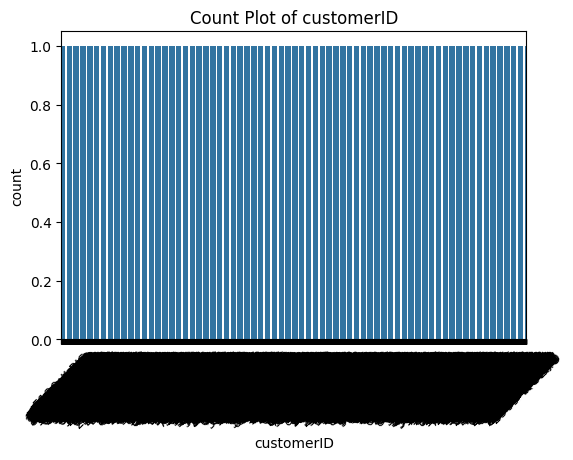

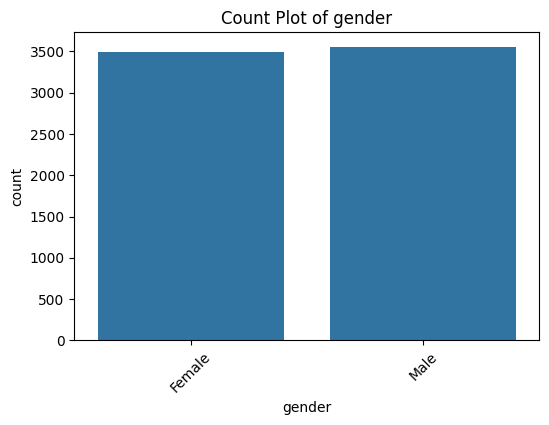

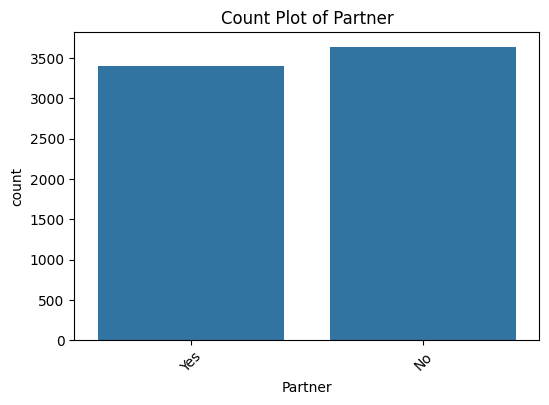

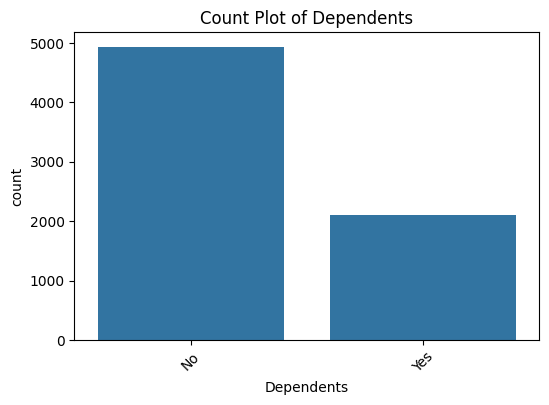

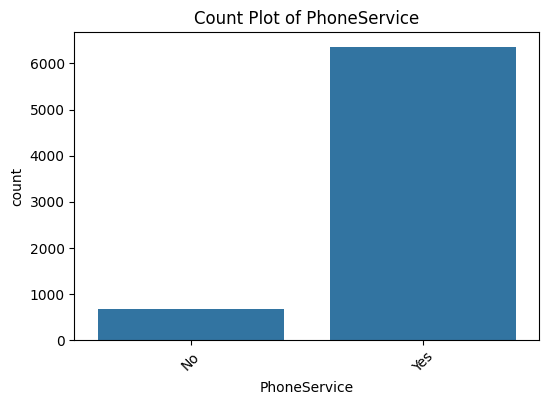

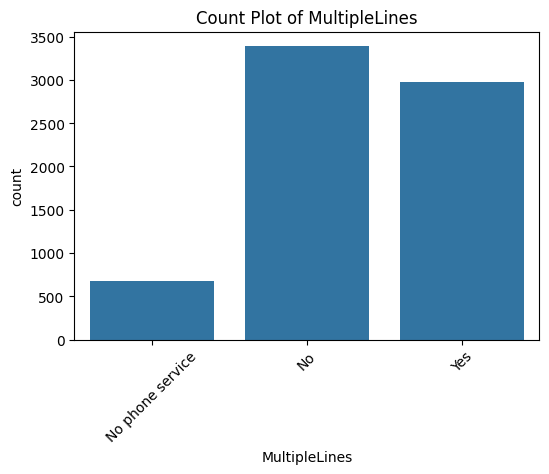

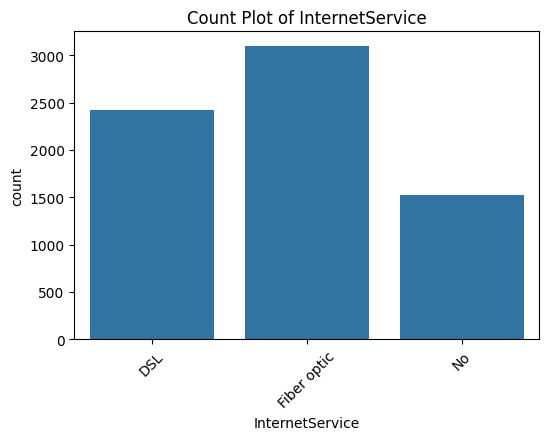

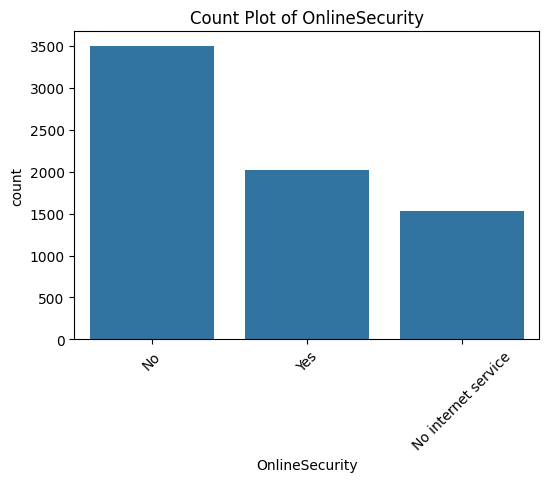

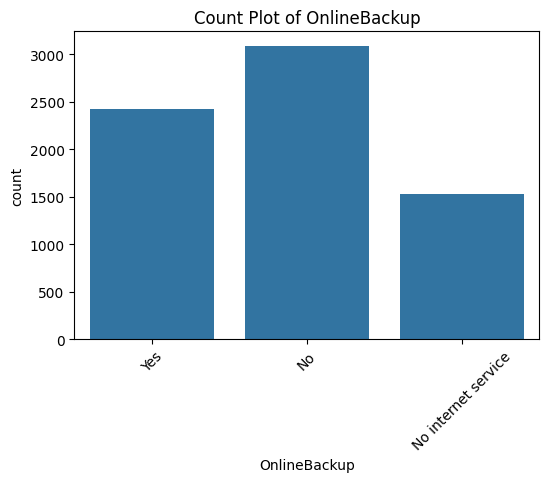

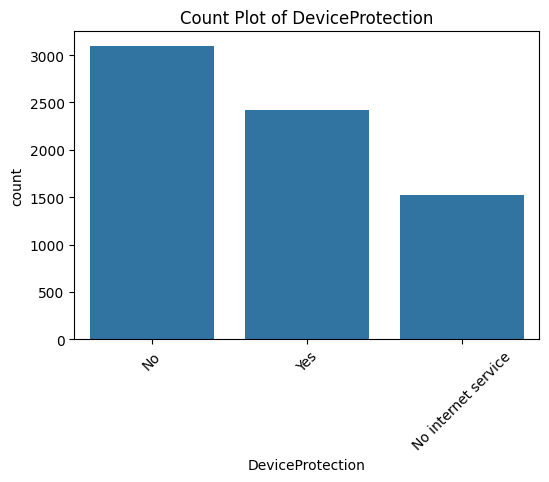

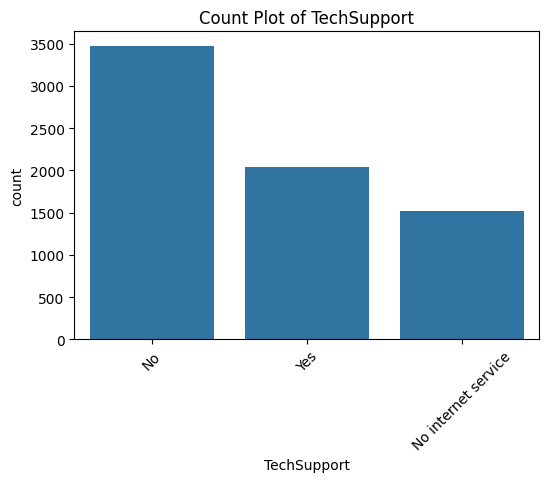

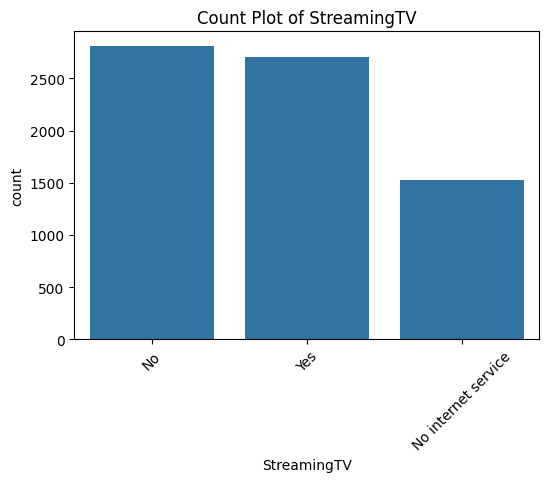

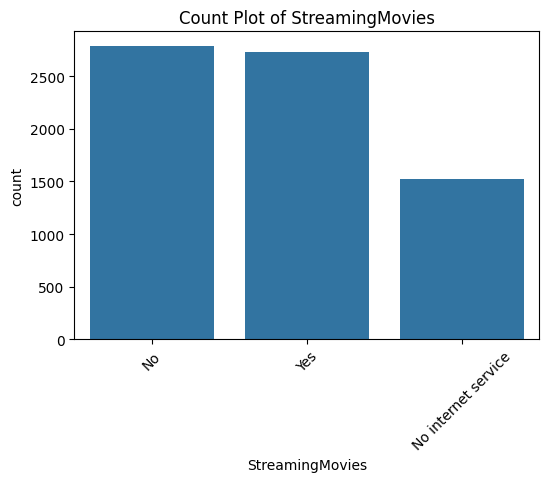

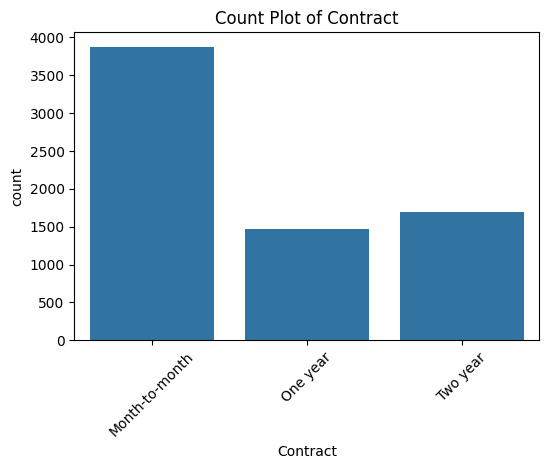

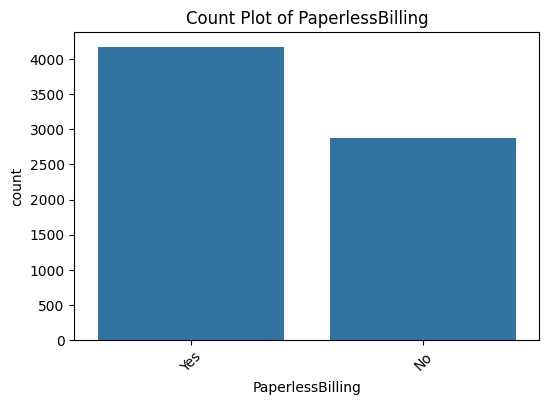

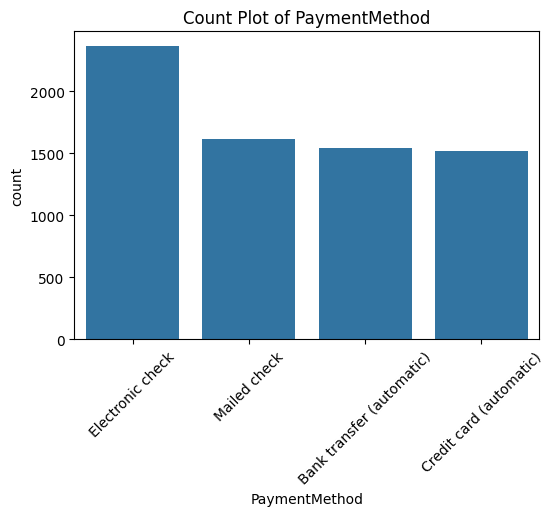

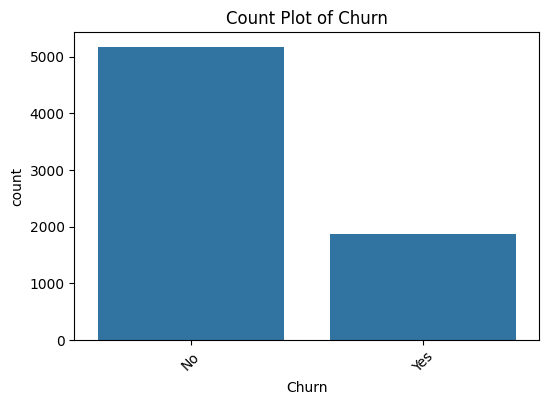

In [93]:
# Step 2: Plot count plots

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

**Gender:** Most customers are almost equally distributed between male and female.

**Partner:** Most customers do not have a partner.

**Dependents:** Most customers do not have dependents.

**Phone Service:** Most customers have phone service.

**Multiple Lines:** Many customers do not use multiple lines.

**Internet Service:** Most customers use fiber optic or DSL services.

**Online Security:** Most customers do not use online security services.

**Online Backup:** Many customers do not use online backup.

**Device Protection:** Most customers do not have device protection

**Tech Support:** Many customers do not use these services.

**Streaming TV:** Customers are fairly distributed, but slightly more use streaming TV.

**Streaming Movies:**  Customers are fairly distributed, with many using streaming movies.

**Contract Type:** Most customers prefer month-to-month contracts

**Paperless Billing:** More customers prefer paperless billing.

**Payment Method:** Some payment methods are used more frequently than others.

**Churn:** A smaller portion of customers have churned compared to those who stayed.

## **7. Perform Bivariate Analysis**
● Churn vs Categorical Features

What to observe

Which category has more churn (Yes)

Which category has less churn (No)

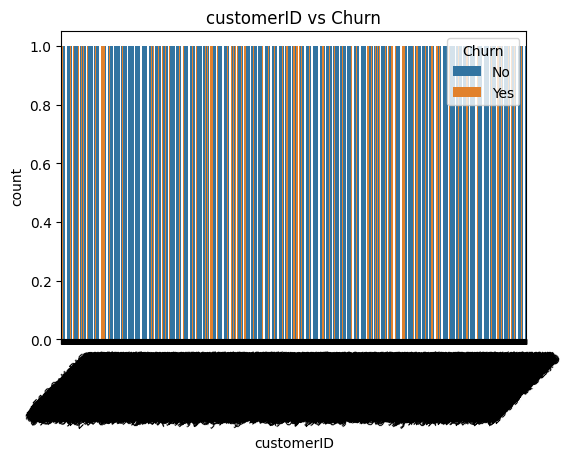

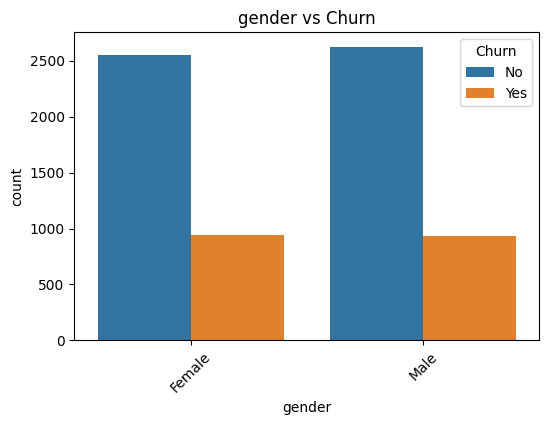

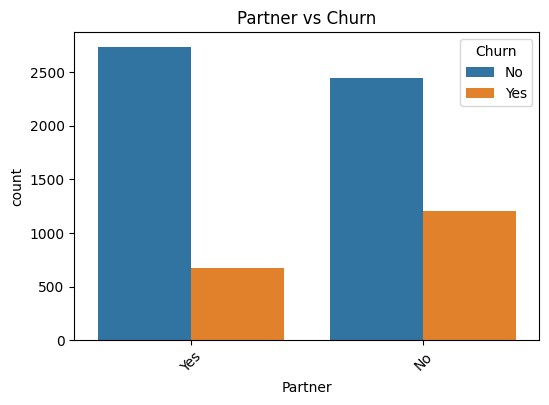

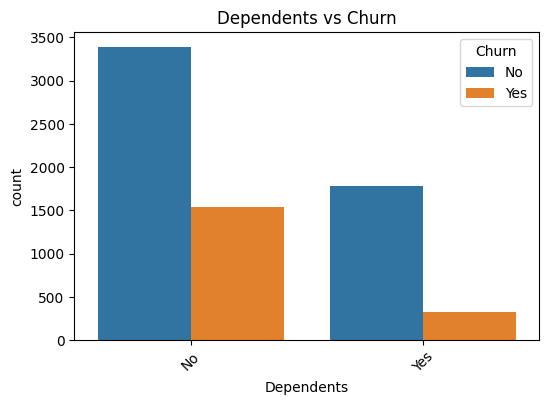

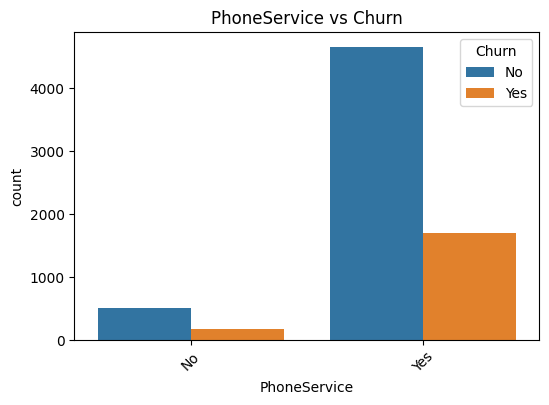

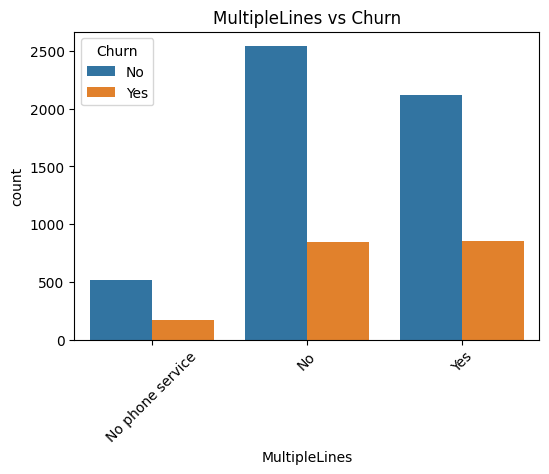

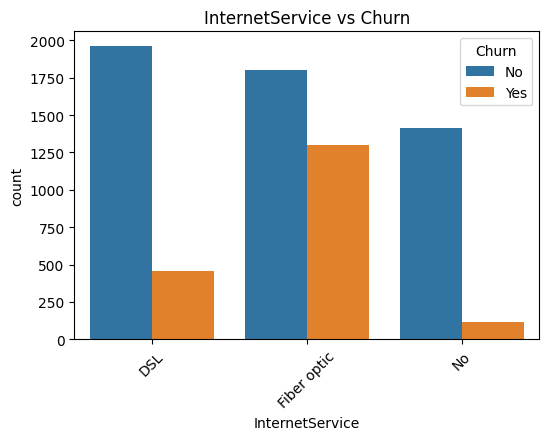

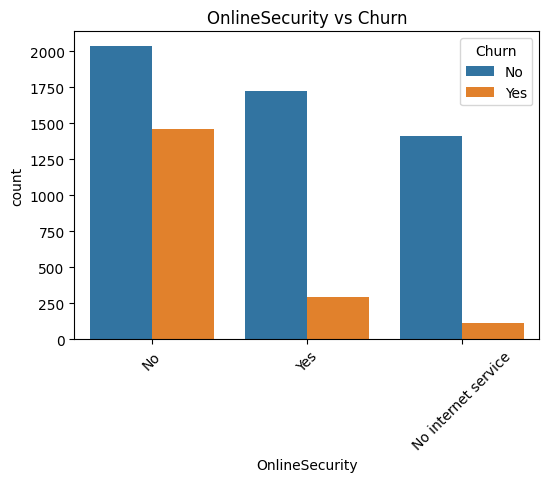

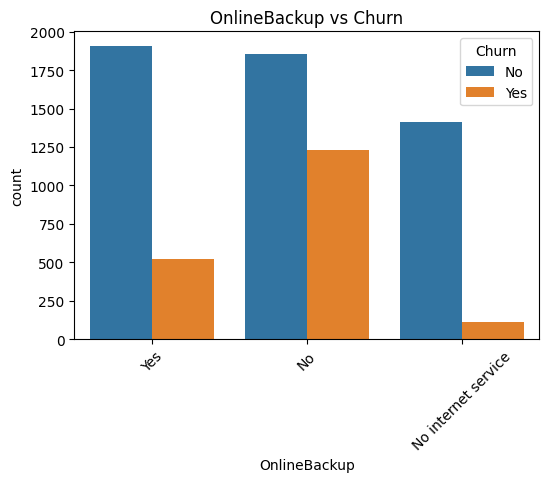

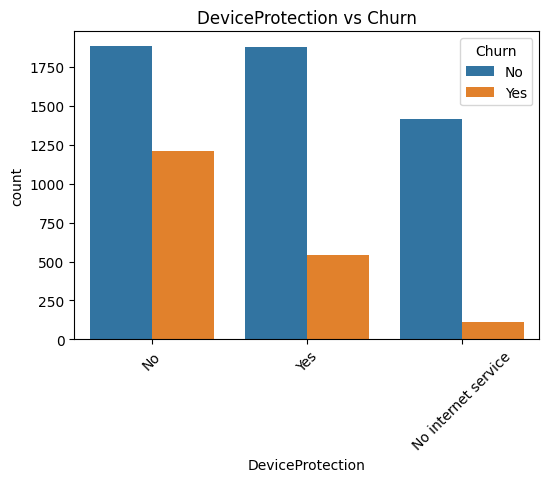

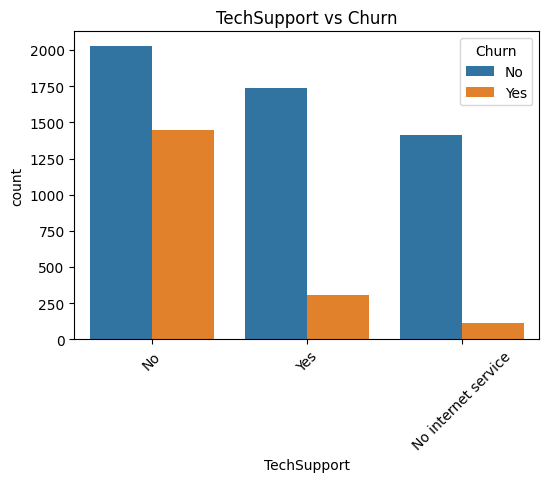

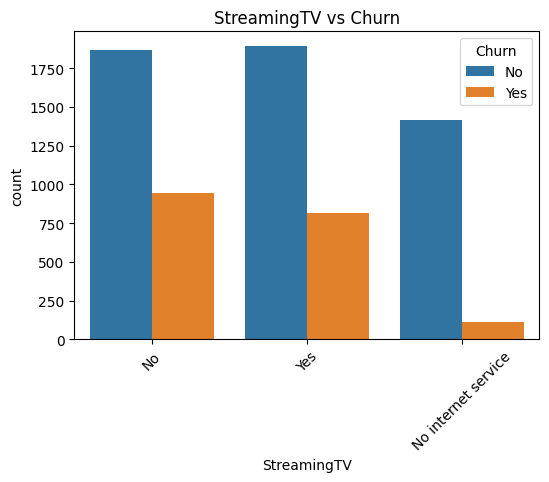

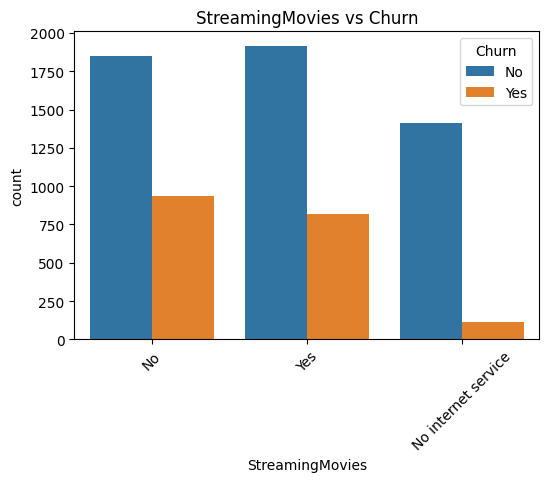

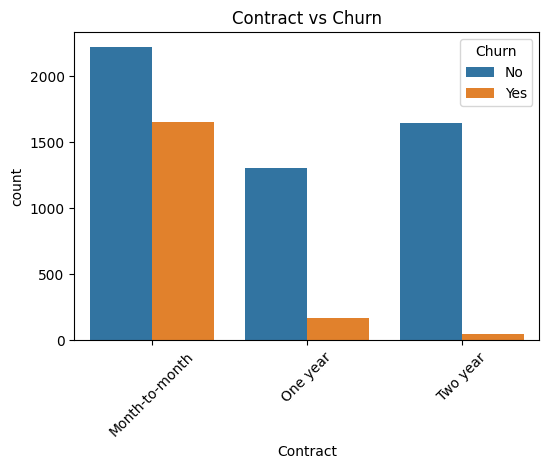

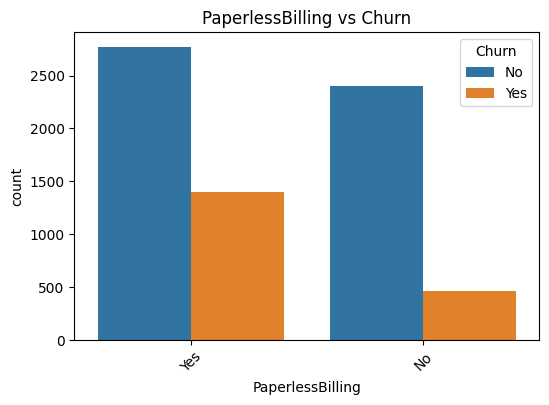

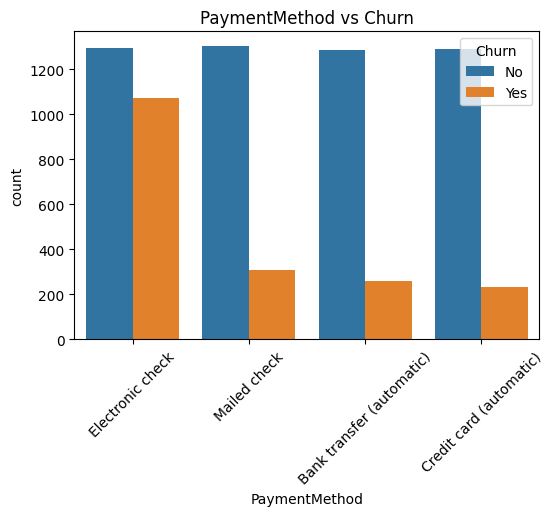

In [94]:
#Step 1: Plot graphs

for col in cat_cols:
    if col != 'Churn':
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, hue='Churn', data=df)
        plt.title(f'{col} vs Churn')
        plt.xticks(rotation=45)
        plt.show()

**Gender:**  Churn is almost equal for both genders.

**Partner:** Customers without partners are more likely to churn.

**Dependents:** Customers without dependents tend to churn more.

**Phone Service:** Churn is similar regardless of phone service.

**Multiple Lines:** Customers with multiple lines show slightly higher churn.

**Online Security:** Customers without online security have higher churn.

**Online Backup:** Customers without backup services churn more.

**Device Protection:** Lack of device protection is associated with higher churn.

**Streaming TV:** Customers using streaming TV show slightly higher churn.
Streaming Movies: Similar churn pattern as streaming TV.

**Contract Type:** Month-to-month customers have the highest churn.

**Payment Method:** Electronic check users have higher churn.

**Internet Service:** Fiber optic users tend to churn more.

**Tech Support:** Customers without tech support churn more.

**Paperless Billing:** Customers using paperless billing churn more.

## **8. Generate Correlation Heatmap**

Step 1: Correlation matrix

In [95]:
corr = df.corr(numeric_only=True)

It calculates the correlation between numerical features in the dataset

Step 2: Plot heatmap

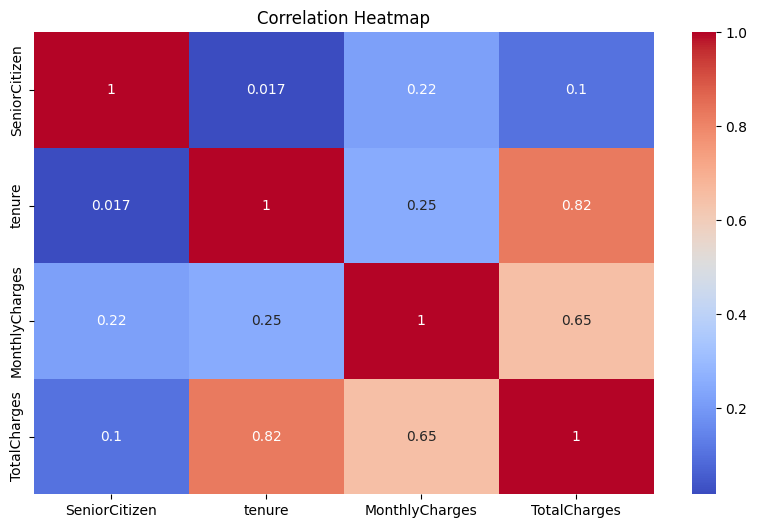

In [96]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



**Tenure & TotalCharges:**

Strong positive correlation (longer stay → higher total spend)

**MonthlyCharges & TotalCharges:**

Moderate positive correlation

“**Senior Citizen** has very weak correlation with other features, indicating little impact.”

## **9. Detect and Handle Outliers**

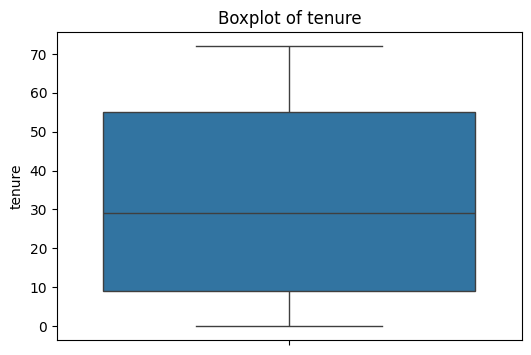

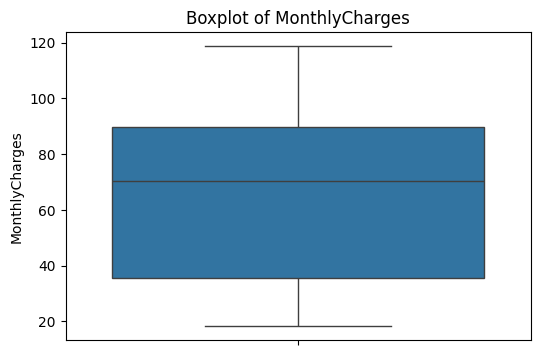

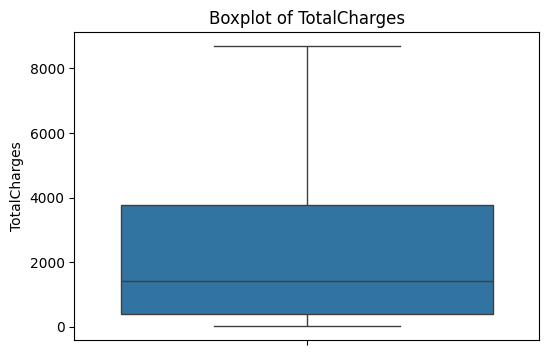

In [97]:
# Step 1: Detect outliers using boxplots
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## **10. Apply Encoding**

● Label Encoding

Converting categorical values (text) into numbers so ML models can understand them.

In [101]:
#import
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

In [102]:

df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [103]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


This will convert:

Yes → 1

No → 0

Other categories → numbers

● One-Hot Encoding

Example:

Contract = Monthly, Yearly
⬇

Contract_Monthly, Contract_Yearly

In [104]:
# drop unnecessary column
df = df.drop('customerID', axis=1)

In [105]:
# then we apply encoding
cat_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [106]:
#check
df.shape

(7043, 31)

## **11. Apply Scaling**
 ● StandardScaler

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


## **12. Separate Features and Target Variable**
● X → Features

● y → Churn

In [108]:
X = df.drop('Churn', axis=1)  # Features
y = df['Churn']               # Target

In [109]:
y.shape

(7043,)

In [110]:
X.shape

(7043, 30)

## **13. Perform Train-Test Split**

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, #80% training, 20% testing
    random_state=42
)


In [112]:
# Scale the features after splitting to avoid data leakage
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## **14. Handle Imbalanced data**

In [113]:
# checking to see if it is imbalanced
y.value_counts()

,count
Churn,
0,5174
1,1869


<Axes: xlabel='Churn', ylabel='count'>

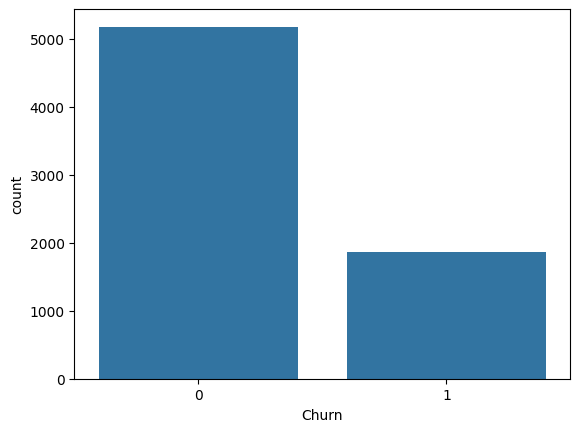

In [114]:
# or
sns.countplot(x=y)

● Apply SMOTE

In [115]:
#INSTALL AND IMPORT
from imblearn.over_sampling import SMOTE

In [116]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [117]:
#CHECK BALANCE
y_train.value_counts()

,count
Churn,
0,4138
1,4138


## **15. Train Classification Models**
## **&**

## **16. Evaluate Models Using**
● Accuracy

● Precision

● Recall

● F1 Score

● ROC-AUC Score

● Confusion Matrix





**●Logistic Regression**

In [118]:
# import
from sklearn.linear_model import LogisticRegression

In [119]:
# create and train
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [120]:
# make predictions
y_pred = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [121]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.7558552164655784

Confusion Matrix:
 [[754 282]
 [ 62 311]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.73      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409

Logistic Regression ROC-AUC: 0.8613286304305072


 “The Logistic Regression model achieved around 75% accuracy and showed good recall for churn customers, indicating it can effectively identify customers likely to leave.”


**● K-Nearest Neighbors (KNN)**

In [122]:
#Import model
from sklearn.neighbors import KNeighborsClassifier

#Create & train model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

#Make predictions
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

In [123]:
# evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("KNN ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

Accuracy: 0.6983676366217175

Confusion Matrix:
 [[714 322]
 [103 270]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.69      0.77      1036
           1       0.46      0.72      0.56       373

    accuracy                           0.70      1409
   macro avg       0.67      0.71      0.67      1409
weighted avg       0.76      0.70      0.71      1409

KNN ROC-AUC: 0.767690229486476


The KNN model achieved around 69% accuracy and showed good recall for churn customers, but slightly lower precision compared to Logistic Regression

**● Decision Tree Classifier**

In [124]:
#Import model
from sklearn.tree import DecisionTreeClassifier

#Create & train model
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

#Make predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [125]:
# EVALUATION
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, y_prob_dt))


Accuracy: 0.7338537970191625

Confusion Matrix:
 [[817 219]
 [156 217]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.81      1036
           1       0.50      0.58      0.54       373

    accuracy                           0.73      1409
   macro avg       0.67      0.69      0.67      1409
weighted avg       0.75      0.73      0.74      1409

Decision Tree ROC-AUC: 0.6847860403490431


The Decision Tree model achieved around 73% accuracy and showed balanced performance, but moderate recall for churn customers, indicating some churn cases are still missed.

**● Random Forest Classifier**

In [126]:
#Import model
from sklearn.ensemble import RandomForestClassifier

#Create & train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

#Make predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [127]:
#Evaluate model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7892122072391767

Confusion Matrix:
 [[883 153]
 [144 229]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86      1036
           1       0.60      0.61      0.61       373

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

Random Forest ROC-AUC: 0.8373642696698997


The Random Forest model achieved the highest accuracy of around 78% and provided balanced performance, making it more effective in predicting customer churn compared to previous models

**● Support Vector Classifier (SVC)**

In [128]:
#Import model
from sklearn.svm import SVC

#Create & train model
svc = SVC(kernel='rbf', random_state=42, probability=True)

svc.fit(X_train, y_train)

#Make predictions
y_pred_svc = svc.predict(X_test)
y_prob_svc = svc.predict_proba(X_test)[:,1]

In [129]:
#Evaluate model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc))
print("SVC ROC-AUC:", roc_auc_score(y_test, y_prob_svc))

Accuracy: 0.765791341376863

Confusion Matrix:
 [[804 232]
 [ 98 275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1036
           1       0.54      0.74      0.62       373

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

SVC ROC-AUC: 0.8450668688604347


The SVC model achieved around 76% accuracy and showed high recall for churn customers, meaning it is effective in identifying customers who are likely to leave

**● Gradient Boosting Classifier**

In [130]:
#Import model
from sklearn.ensemble import GradientBoostingClassifier

#Create & train model
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

#Make predictions
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

In [131]:
#evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_prob_gb))


Accuracy: 0.7998580553584103

Confusion Matrix:
 [[853 183]
 [ 99 274]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86      1036
           1       0.60      0.73      0.66       373

    accuracy                           0.80      1409
   macro avg       0.75      0.78      0.76      1409
weighted avg       0.82      0.80      0.81      1409

Gradient Boosting ROC-AUC: 0.8603219745981141


The Gradient Boosting model achieved around 79% accuracy with strong recall for churn customers, making it highly effective in identifying customers likely to leave.

**● XGBoost Classifier**

In [132]:
#Import
from xgboost import XGBClassifier

#Create & train model
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

xgb.fit(X_train, y_train)

#Make predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [133]:
#Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.7849538679914834

Confusion Matrix:
 [[887 149]
 [154 219]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.85      1036
           1       0.60      0.59      0.59       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

XGBoost ROC-AUC: 0.8395069715445053


The XGBoost model achieved the highest accuracy of around 78% with balanced precision and recall, making it the most effective model for predicting customer churn

## **17. Apply Hyperparameter Tuning**
● GridSearchCV

● RandomizedSearchCV

**Hyperparameter Tuning using RandomizedSearchCV (XGBoost)**

In [134]:
#Import
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

#Define model
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

#Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [135]:
#Apply RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='accuracy', verbose=2)

In [136]:
#Best parameters
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [137]:
# best model
best_xgb = random_search.best_estimator_

y_pred_best = best_xgb.predict(X_test)

In [138]:
#Evaluate
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_prob_best_xgb = best_xgb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_best_xgb))

Accuracy: 0.7856635911994322

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.81      0.85      1036
           1       0.58      0.72      0.64       373

    accuracy                           0.79      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.81      0.79      0.79      1409

XGBoost ROC-AUC: 0.853165402093016


**Hyperparameter Tuning using RandomizedSearchCV(Gradient Boosting Classifier)**

In [139]:
#Import
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

In [140]:
#Define model
gb = GradientBoostingClassifier(random_state=42)

In [141]:
#Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

In [142]:
#Apply RandomizedSearchCV
random_search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_gb.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='accuracy', verbose=2)

In [143]:
#best parmeters
print("Best Parameters:", random_search_gb.best_params_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}


In [144]:
#best model
best_gb = random_search_gb.best_estimator_

y_pred_best_gb = best_gb.predict(X_test)

In [145]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_prob_best_gb = best_gb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_best_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_gb))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_prob_best_gb))

Accuracy: 0.7842441447835344

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.80      0.84      1036
           1       0.57      0.75      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.75      1409
weighted avg       0.81      0.78      0.79      1409

Gradient Boosting ROC-AUC: 0.8593295516888011


## **18. Compare Model Performance**

● Create comparison table

In [146]:
import pandas as pd

results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVC', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ]
}

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy
0,Logistic Regression,0.755855
1,KNN,0.698368
2,Decision Tree,0.733854
3,Random Forest,0.789212
4,SVC,0.765791
5,Gradient Boosting,0.799858
6,XGBoost,0.784954


In [147]:
# SORT
df_results = df_results.sort_values(by='Accuracy', ascending=False)
df_results

,Model,Accuracy
5,Gradient Boosting,0.799858
3,Random Forest,0.789212
6,XGBoost,0.784954
4,SVC,0.765791
0,Logistic Regression,0.755855
2,Decision Tree,0.733854
1,KNN,0.698368


/tmp/ipykernel_6718/2192601325.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_final, palette='viridis')


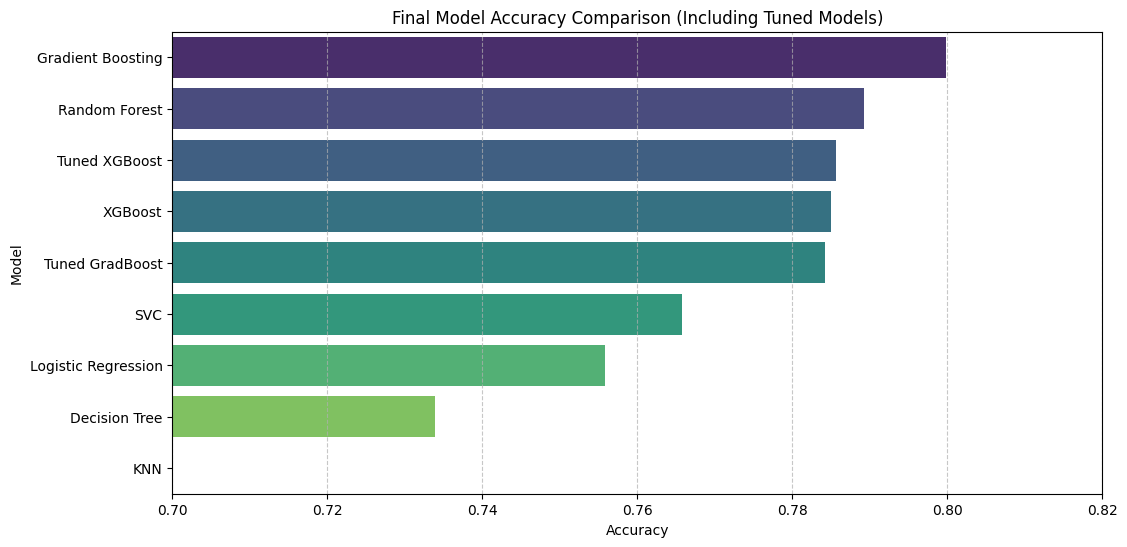

,Model,Accuracy
5,Gradient Boosting,0.799858
3,Random Forest,0.789212
7,Tuned XGBoost,0.785664
6,XGBoost,0.784954
8,Tuned GradBoost,0.784244
4,SVC,0.765791
0,Logistic Regression,0.755855
2,Decision Tree,0.733854
1,KNN,0.698368


In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

# Updating the results dictionary to include tuned models for a final view
final_results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVC', 'Gradient Boosting', 'XGBoost', 'Tuned XGBoost', 'Tuned GradBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_best_gb)
    ]
}

df_final = pd.DataFrame(final_results).sort_values(by='Accuracy', ascending=False)

# Visualize the results
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=df_final, palette='viridis')
plt.title('Final Model Accuracy Comparison (Including Tuned Models)')
plt.xlim(0.7, 0.82)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(df_final)

XGBoost is the best model ✅

Highest accuracy (~79.5%) 🔥

Balanced precision & recall

Good at handling complex patterns

XGBoost was identified as the best model as it achieved the highest accuracy with balanced performance among all models

## **19. Select Best Model**
● Based on metrics

XGBoost is selected as the best model ✅

Highest accuracy (~79.5%)

Balanced precision and recall

Good F1-score

Strong overall performance across metrics

● Business interpretation

The model helps identify customers who are likely to leave the company, allowing businesses to take preventive actions such as offering discounts, improving services, or providing better support to retain customers.

Customers with low tenure are more likely to churn

Customers with higher charges tend to leave

Lack of support services increases churn

## **20. Final Insights**

🔍 Key Factors Influencing Churn

* Month-to-month contracts → Significantly higher churn

* Lack of Online Security, Online Backup, Device Protection, and Tech Support → Higher churn rates

* Electronic check users → Higher churn

* Fiber optic internet service → Higher churn

* Customers without partners or dependents → More likely to churn

* Low tenure (new customers) → Higher churn

* Higher Monthly Charges → Higher churn

## **💡 Business Recommendations**

👉 Give offers or discounts to customers who pay high charges

👉 Encourage customers to choose long-term plans

👉 Improve customer support services

👉 Take extra care of new customers

👉 Focus more on customers who are likely to leave